In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures
sns.set_theme()

# Подготовка набора данных

In [2]:
(diamonds := pd.read_csv("diamonds.csv"))

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
diamonds.drop(columns=["Unnamed: 0"], inplace=True)
diamonds.drop_duplicates(inplace=True)
diamonds.reset_index(drop=True, inplace=True)
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53789,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53790,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53791,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53792,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
diamonds[(diamonds == 0).sum(axis=1) > 1]

,carat,cut,color,clarity,depth,table,price,x,y,z
11156,1.07,Ideal,F,SI2,61.6,56.0,4954,0.0,6.62,0.0
11935,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.00,0.0
15914,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.00,0.0
24464,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.00,0.0
26183,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.00,0.0
27364,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.00,0.0
49413,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0


In [5]:
diamonds.drop(diamonds[(diamonds == 0).sum(axis=1) > 1].index, inplace=True)
diamonds[(diamonds == 0).sum(axis=1) > 1]

,carat,cut,color,clarity,depth,table,price,x,y,z


In [6]:
diamonds_index = diamonds[(diamonds == 0).sum(axis=1) > 0].index
diamonds.loc[diamonds_index]

,carat,cut,color,clarity,depth,table,price,x,y,z
2201,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2308,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4778,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5457,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10145,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
13570,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
24338,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0
26063,2.25,Premium,I,SI1,61.3,58.0,15397,8.52,8.42,0.0
27047,2.20,Premium,H,SI1,61.2,59.0,17265,8.42,8.37,0.0
27438,2.02,Premium,H,VS2,62.7,53.0,18207,8.02,7.95,0.0


In [7]:
diamonds.loc[diamonds_index, "z"] = round(
    diamonds.depth * (diamonds.x + diamonds.y) / 200, 2
)
diamonds.loc[diamonds_index]

,carat,cut,color,clarity,depth,table,price,x,y,z
2201,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,3.85
2308,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,3.85
4778,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,4.09
5457,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,3.84
10145,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,4.54
13570,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,4.06
24338,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,5.03
26063,2.25,Premium,I,SI1,61.3,58.0,15397,8.52,8.42,5.19
27047,2.20,Premium,H,SI1,61.2,59.0,17265,8.42,8.37,5.14
27438,2.02,Premium,H,VS2,62.7,53.0,18207,8.02,7.95,5.01


In [8]:
diamonds_index = diamonds[(diamonds.y > 15) | (diamonds.z > 10)].index
diamonds.loc[diamonds_index]

,carat,cut,color,clarity,depth,table,price,x,y,z
24012,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06
48268,0.51,Very Good,E,VS1,61.8,54.7,1970,5.12,5.15,31.80
49047,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12


In [9]:
diamonds.drop(diamonds_index, inplace=True)
diamonds.reset_index(drop=True, inplace=True)
diamonds[(diamonds.y > 15) | (diamonds.z > 10)]

,carat,cut,color,clarity,depth,table,price,x,y,z


In [10]:
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53779,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53780,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53781,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53782,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [11]:
cut_encoder = OrdinalEncoder(categories=[["Fair", "Good", "Very Good", "Premium", "Ideal"]])
color_encoder = OrdinalEncoder(categories=[["J", "I", "H", "G", "F", "E", "D"]])
clarity_encoder = OrdinalEncoder(categories=[["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]])
diamonds.cut = cut_encoder.fit_transform(diamonds[["cut"]])
diamonds.color = color_encoder.fit_transform(diamonds[["color"]])
diamonds.clarity = clarity_encoder.fit_transform(diamonds[["clarity"]])
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53779,0.72,4.0,6.0,2.0,60.8,57.0,2757,5.75,5.76,3.50
53780,0.72,1.0,6.0,2.0,63.1,55.0,2757,5.69,5.75,3.61
53781,0.70,2.0,6.0,2.0,62.8,60.0,2757,5.66,5.68,3.56
53782,0.86,3.0,2.0,1.0,61.0,58.0,2757,6.15,6.12,3.74


In [12]:
(y := diamonds.price)

0         326
1         326
2         327
3         334
4         335
         ... 
53779    2757
53780    2757
53781    2757
53782    2757
53783    2757
Name: price, Length: 53784, dtype: int64

In [13]:
(X := diamonds.drop(columns="price"))

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,4.0,5.0,1.0,61.5,55.0,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,59.8,61.0,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,56.9,65.0,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,62.4,58.0,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,63.3,58.0,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...
53779,0.72,4.0,6.0,2.0,60.8,57.0,5.75,5.76,3.50
53780,0.72,1.0,6.0,2.0,63.1,55.0,5.69,5.75,3.61
53781,0.70,2.0,6.0,2.0,62.8,60.0,5.66,5.68,3.56
53782,0.86,3.0,2.0,1.0,61.0,58.0,6.15,6.12,3.74


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Своя реализация линейной регрессии

In [15]:
class MyLinearRegression:
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        
        self.coef_ = None
        self.intercept_ = None
        self.n_features_in_ = None
    
    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        self.n_features_in_ = X.shape[1]
        
        if self.fit_intercept:
            X = np.hstack([np.ones((X.shape[0], 1)), X])
        
        try:
            theta = np.linalg.pinv(X.T @ X) @ X.T @ y
        except np.linalg.LinAlgError:
            theta = np.linalg.lstsq(X, y, rcond=None)[0]
        
        if self.fit_intercept:
            self.intercept_ = theta[0]
            self.coef_ = theta[1:]
        else:
            self.intercept_ = 0.0
            self.coef_ = theta
        
        return self
    
    def predict(self, X):
        if self.coef_ is None:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X = np.array(X, dtype=float)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Ошибка: ожидается {self.n_features_in_} признаков, а получено {X.shape[1]}")
        
        if self.fit_intercept:
            return self.intercept_ + X @ self.coef_
        else:
            return X @ self.coef_
    
    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = np.array(y, dtype=float)
        
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        
        if ss_tot == 0:
            return 1.0 if ss_res == 0 else 0.0
        
        return (1 - ss_res / ss_tot).item()

# Сравнение библиотечной реализации со своей

In [16]:
reg1 = LinearRegression(fit_intercept=True)
reg1.fit(X_train, y_train)
reg1.score(X_test, y_test)

0.9029382183230101

In [17]:
reg2 = MyLinearRegression(fit_intercept=True)
reg2.fit(X_train, y_train)
reg2.score(X_test, y_test)

0.9029382183229119

In [18]:
reg1.coef_

array([11188.66968814,   130.78456549,   324.95696862,   494.36889672,
          54.77508292,   -21.8849156 , -1781.19348547,  2129.31636726,
       -2221.5416016 ])

In [19]:
reg2.coef_

array([11188.66968818,   130.78456549,   324.95696862,   494.36889672,
          54.77508288,   -21.8849156 , -1781.1934856 ,  2129.31636705,
       -2221.54160105])

In [20]:
reg1.intercept_

np.float64(-4245.220456504025)

In [21]:
reg2.intercept_

np.float64(-4245.220453533844)

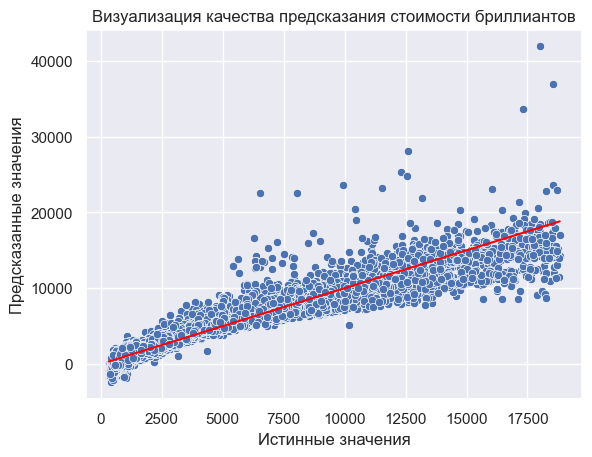

In [22]:
sns.scatterplot(x=y_test, y=reg1.predict(X_test))
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color="red")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Визуализация качества предсказания стоимости бриллиантов");

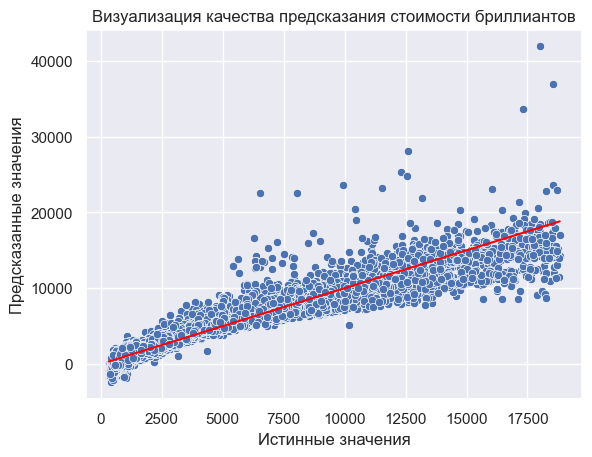

In [23]:
sns.scatterplot(x=y_test, y=reg2.predict(X_test))
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color="red")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Визуализация качества предсказания стоимости бриллиантов");

# Своя реализация полиномиальной регрессии

In [24]:
class MyPolynomialRegression:
    def __init__(self, degree=2, include_bias=True):
        self.degree = degree
        self.include_bias = include_bias

        self.linear_reg = MyLinearRegression(fit_intercept=not include_bias)
        self.n_features_in_ = None
    
    def __create_polynomial_features(self, X):
        n_samples, n_features = X.shape
        features = []

        if self.include_bias:
            features.append(np.ones((n_samples, 1)))
        
        if n_features == 1:
            for d in range(1, self.degree + 1):
                features.append(X ** d)
        else:
            features.append(X)
            for d in range(2, self.degree + 1):
                features.append(X ** d)
            
        return np.hstack(features)
    
    def fit(self, X, y):
        X = np.array(X, dtype=float)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        self.n_features_in_ = X.shape[1]
        
        X_poly = self.__create_polynomial_features(X)
        
        self.linear_reg.fit(X_poly, y)
        
        return self
    
    def predict(self, X):
        X = np.array(X, dtype=float)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Ошибка: ожидается {self.n_features_in_} признаков, а получено {X.shape[1]}")
        
        X_poly = self.__create_polynomial_features(X)
        
        return self.linear_reg.predict(X_poly)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = np.array(y, dtype=float)
        
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        
        if ss_tot == 0:
            return 1.0 if ss_res == 0 else 0.0
        
        return (1 - ss_res / ss_tot).item()
    
    @property
    def coef_(self):
        return self.linear_reg.coef_
    
    @property
    def intercept_(self):
        return self.linear_reg.intercept_

# Сравнение библиотечной реализации со своей

In [25]:
pf = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = pf.fit_transform(X_train)
X_test_poly = pf.transform(X_test)
poly1 = LinearRegression(fit_intercept=False)
poly1.fit(X_train_poly, y_train)
poly1.score(X_test_poly, y_test)

0.9624731331532698

In [26]:
poly2 = MyPolynomialRegression(degree=2, include_bias=True)
poly2.fit(X_train, y_train)
poly2.score(X_test, y_test)

0.9274679590425844

In [27]:
poly1.coef_

array([-7.23631081e+04, -3.79436580e+04,  3.66036226e+03, -1.91491798e+03,
       -3.57682860e+02,  4.96441969e+02,  1.50075574e+03, -1.15431228e+04,
        2.03796984e+04,  2.36380521e+03, -9.74722797e+03,  4.18355675e+02,
        5.81995697e+02,  1.47950962e+03, -9.62577474e+01,  1.32958224e+02,
       -1.87687053e+02,  4.72041908e+03,  7.78509670e+03,  2.02658179e+00,
        1.88552004e+01,  5.63981872e+00, -5.42311332e+01, -3.26591835e+00,
       -4.91228861e+02, -2.69769645e+02,  1.10135810e+03, -2.73507041e+01,
        1.23063536e+02,  1.54303615e+01,  1.45040529e+00, -6.33860494e+01,
        2.40229733e+02, -1.42951524e+02, -2.42098323e+00,  6.47965113e+00,
       -6.14307550e+00,  2.78831449e+02, -2.72100141e+02, -2.20121398e+02,
        3.36480678e+00, -1.82402858e+01,  3.49643275e+02, -1.66359370e+02,
       -2.30319308e+02, -1.01951761e+00,  7.68844824e+00, -2.93405525e+02,
        3.61041192e+02, -2.04061052e+02, -5.95824478e+02, -1.35219968e+03,
        1.33128806e+03, -

In [28]:
poly2.coef_

array([-4.41670489e+03,  1.22689218e+04,  2.13944700e+02,  7.83481802e+02,
        1.15653812e+03,  7.93470131e+02, -3.32651606e+01,  1.24098552e+04,
       -2.17755197e+04, -1.05886193e+02, -2.25029651e+03, -2.33789606e+01,
       -6.89561822e+01, -9.81641814e+01, -6.66956608e+00,  1.02610138e-01,
       -1.13613702e+03,  1.92458518e+03,  1.00534112e+02])

In [29]:
poly1.intercept_

0.0

In [30]:
poly2.intercept_

0.0

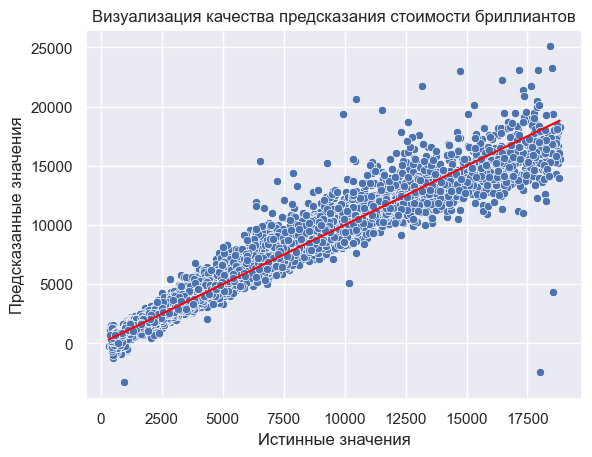

In [31]:
sns.scatterplot(x=y_test, y=poly1.predict(X_test_poly))
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color="red")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Визуализация качества предсказания стоимости бриллиантов");

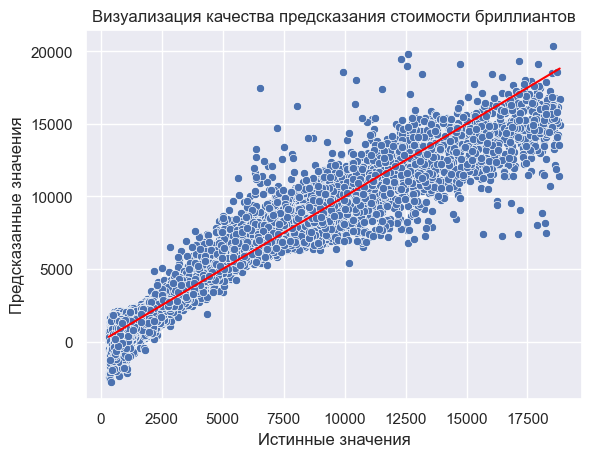

In [32]:
sns.scatterplot(x=y_test, y=poly2.predict(X_test))
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color="red")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Визуализация качества предсказания стоимости бриллиантов");